# RQ3 – Model Stability

Measures model accuracy/F1 across sequential monitoring windows from the provided cybersecurity dataset.

In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

OUTPUT_DIR = "responsible_ai_outputs"
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables_csv")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures_pdf")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def find_file(possible_names):
    """Find uploaded dataset in current folder, /mnt/data, or Kaggle input folders."""
    search_roots = [".", "/mnt/data", "/kaggle/input"]
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for name in possible_names:
            matches = glob.glob(os.path.join(root, "**", name), recursive=True)
            if matches:
                return matches[0]

    all_csvs = []
    for root in search_roots:
        if os.path.exists(root):
            all_csvs += glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    for f in all_csvs:
        base = os.path.basename(f).lower()
        for name in possible_names:
            token = name.replace("(1)", "").replace(".csv","").lower()
            if token in base:
                return f
    raise FileNotFoundError(f"Could not find any of: {possible_names}")

CYBER_FILE = find_file([
    "cybersecurity_intrusion_data(1).csv",
    "cybersecurity_intrusion_data.csv"
])
cyber = pd.read_csv(CYBER_FILE)

target_col = "attack_detected"
drop_cols = ["session_id"]
cyber = cyber.drop(columns=[c for c in drop_cols if c in cyber.columns])

X = cyber.drop(columns=[target_col])
y = cyber[target_col].astype(int)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
}
print("Loaded:", CYBER_FILE)
print("Dataset shape:", cyber.shape)
print("Metrics:", metrics)

def save_bar(df, x, y, title, xlabel, ylabel, filename, rotation=30):
    plt.figure(figsize=(8, 4.8))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)

Loaded: ./cybersecurity_intrusion_data.csv
Dataset shape: (9537, 10)
Metrics: {'accuracy': 0.8846960167714885, 'precision': 1.0, 'recall': 0.7420262664165104, 'f1': 0.8519116855142703}


Saved table: responsible_ai_outputs/tables_csv/RQ3_model_stability_over_windows.csv


,Monitoring_Window,Accuracy,Precision,Recall,F1_Score,Records
0,M1,0.9015,1.0,0.7788,0.8757,1908
1,M2,0.8804,1.0,0.7394,0.8502,1907
2,M3,0.9004,1.0,0.7716,0.8711,1907
3,M4,0.8951,1.0,0.7688,0.8693,1907
4,M5,0.8915,1.0,0.7542,0.8599,1908


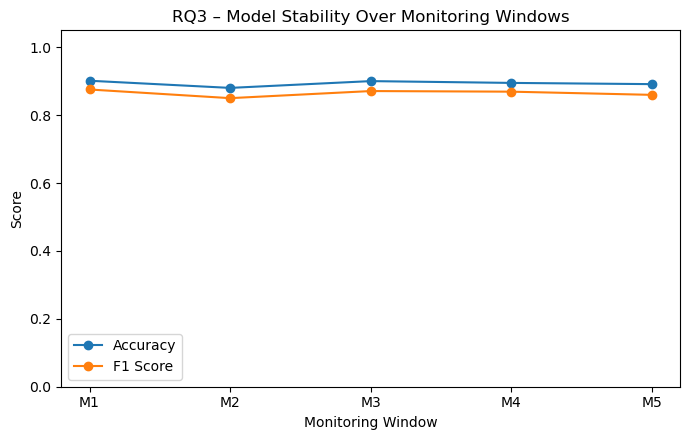

Saved figure: responsible_ai_outputs/figures_pdf/RQ3_model_stability.pdf


In [2]:
df_ordered = cyber.reset_index(drop=True).copy()
df_ordered["monitoring_window"] = pd.qcut(df_ordered.index, q=5, labels=["M1", "M2", "M3", "M4", "M5"])

rows = []
for window, g in df_ordered.groupby("monitoring_window"):
    X_g = g.drop(columns=[target_col, "monitoring_window"])
    y_g = g[target_col].astype(int)
    pred_g = clf.predict(X_g)
    rows.append({
        "Monitoring_Window": str(window),
        "Accuracy": round(accuracy_score(y_g, pred_g), 4),
        "Precision": round(precision_score(y_g, pred_g, zero_division=0), 4),
        "Recall": round(recall_score(y_g, pred_g, zero_division=0), 4),
        "F1_Score": round(f1_score(y_g, pred_g, zero_division=0), 4),
        "Records": len(g)
    })

stability_df = pd.DataFrame(rows)
csv_path = os.path.join(TABLE_DIR, "RQ3_model_stability_over_windows.csv")
stability_df.to_csv(csv_path, index=False)
print("Saved table:", csv_path)
display(stability_df)

plt.figure(figsize=(7, 4.5))
plt.plot(stability_df["Monitoring_Window"], stability_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(stability_df["Monitoring_Window"], stability_df["F1_Score"], marker="o", label="F1 Score")
plt.title("RQ3 – Model Stability Over Monitoring Windows")
plt.xlabel("Monitoring Window")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
path = os.path.join(FIG_DIR, "RQ3_model_stability.pdf")
plt.savefig(path, format="pdf", bbox_inches="tight")
plt.show()
print("Saved figure:", path)